In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Confirm everything loaded
print("All imports successful")
print(f"pandas: {pd.__version__}")
print(f"yfinance: {yf.__version__}")

All imports successful
pandas: 2.3.3
yfinance: 1.4.1


In [2]:
# Load MPC decisions
mpc_df = pd.read_csv('../data/rbi_mpc_decisions.csv')
mpc_df['Date'] = pd.to_datetime(mpc_df['Date'], dayfirst=True)

# Verify
print(f"Shape: {mpc_df.shape}")
print(f"\nFirst date: {mpc_df['Date'].iloc[0]}")  # Must show 2016-10-04, not 2016-04-10
print(f"Last date:  {mpc_df['Date'].iloc[-1]}")
print(f"\nDecision counts:\n{mpc_df['Decision'].value_counts()}")
print(f"\nRate change range: {mpc_df['Rate_Change_bps'].min()} to {mpc_df['Rate_Change_bps'].max()} bps")

Shape: (52, 4)

First date: 2016-10-04 00:00:00
Last date:  2025-02-07 00:00:00

Decision counts:
Decision
Hold    34
Cut     10
Hike     8
Name: count, dtype: int64

Rate change range: -75 to 50 bps


In [3]:
# Download Nifty 50
print("Downloading Nifty 50 data...")
nifty_raw = yf.download('^NSEI', start='2015-01-01', end='2025-12-31', progress=False)

# yfinance sometimes returns MultiIndex columns - flatten if needed
if isinstance(nifty_raw.columns, pd.MultiIndex):
    nifty_raw.columns = nifty_raw.columns.get_level_values(0)

# Calculate daily returns
nifty_raw['Return'] = nifty_raw['Close'].pct_change() * 100

# Verify
print(f"Shape: {nifty_raw.shape}")
print(f"Date range: {nifty_raw.index[0].date()} to {nifty_raw.index[-1].date()}")
print(f"Missing returns: {nifty_raw['Return'].isna().sum()}")
print(f"\nSample (first 3 rows):")
print(nifty_raw[['Close', 'Return']].head(3))

Shape: (2707, 6)
Date range: 2015-01-02 to 2025-12-30
Missing returns: 1

Sample (first 3 rows):
Price             Close    Return
Date                             
2015-01-02  8395.450195       NaN
2015-01-05  8378.400391 -0.203084
2015-01-06  8127.350098 -2.996399


In [4]:
# Make a clean return series
nifty_returns = nifty_raw['Return'].copy()

# Strip timezone if present (prevents silent NaN on all merges)
if nifty_returns.index.tz is not None:
    nifty_returns.index = nifty_returns.index.tz_localize(None)

# Normalize to midnight to ensure date-only matching
nifty_returns.index = nifty_returns.index.normalize()

# Map each MPC date to its Nifty return
mpc_df['Nifty_Return'] = mpc_df['Date'].map(nifty_returns)

# Diagnosis
matched = mpc_df['Nifty_Return'].notna().sum()
print(f"Matched: {matched} / {len(mpc_df)} MPC dates")
print(f"Unmatched: {mpc_df['Nifty_Return'].isna().sum()}")

# Show any unmatched dates - these are likely holidays or off-cycle meetings
if mpc_df['Nifty_Return'].isna().any():
    print("\nUnmatched dates:")
    print(mpc_df[mpc_df['Nifty_Return'].isna()][['Date', 'Decision', 'Rate_Change_bps']])

Matched: 52 / 52 MPC dates
Unmatched: 0


In [5]:
# Basic summary: raw returns by decision type
summary = mpc_df.groupby('Decision')['Nifty_Return'].agg(['mean', 'median', 'std', 'count'])
summary.columns = ['Mean_Return', 'Median_Return', 'Std_Dev', 'Count']
summary = summary.round(4)

# Normal day baseline for comparison
normal_mean = nifty_raw['Return'].mean()
normal_std = nifty_raw['Return'].std()

print("=== Average Nifty Returns on MPC Days ===")
print(summary)
print(f"\nNormal day average (all 2707 days): {normal_mean:.4f}%")
print(f"Normal day std dev: {normal_std:.4f}%")

=== Average Nifty Returns on MPC Days ===
          Mean_Return  Median_Return  Std_Dev  Count
Decision                                            
Cut           -0.4564        -0.3612   0.6106     10
Hike           0.0314        -0.0008   1.1808      8
Hold           0.1584         0.1003   0.8965     34

Normal day average (all 2707 days): 0.0470%
Normal day std dev: 1.0236%


In [6]:
def calculate_abnormal_return(date, returns, estimation_window=250, exclusion=30):
    """
    Abnormal return = actual return minus mean return 
    during estimation window (250 days before, excluding 30 days pre-event)
    """
    try:
        idx = returns.index.get_loc(date)
    except KeyError:
        return np.nan
    
    if idx < estimation_window:
        return np.nan
    
    estimation_returns = returns.iloc[idx - estimation_window : idx - exclusion]
    normal_return = estimation_returns.mean()
    actual_return = returns.iloc[idx]
    return actual_return - normal_return

# Apply to all MPC dates
nifty_returns_clean = nifty_raw['Return'].dropna()

mpc_df['Abnormal_Return'] = mpc_df['Date'].apply(
    lambda x: calculate_abnormal_return(x, nifty_returns_clean)
)

print(f"Abnormal returns calculated: {mpc_df['Abnormal_Return'].notna().sum()} / {len(mpc_df)}")
print(f"Dropped (insufficient history): {mpc_df['Abnormal_Return'].isna().sum()}")

# Summary by decision type
ab_summary = mpc_df.groupby('Decision')['Abnormal_Return'].agg(['mean', 'std', 'count']).round(4)
print(f"\n=== Abnormal Returns by Decision ===")
print(ab_summary)

Abnormal returns calculated: 52 / 52
Dropped (insufficient history): 0

=== Abnormal Returns by Decision ===
            mean     std  count
Decision                       
Cut      -0.4706  0.6054     10
Hike      0.0043  1.1938      8
Hold      0.0807  0.8934     34


In [7]:
from scipy import stats

print("=== Statistical Significance Tests ===\n")

decisions = ['Cut', 'Hike', 'Hold']

for decision in decisions:
    returns = mpc_df[mpc_df['Decision'] == decision]['Abnormal_Return'].dropna()
    t_stat, p_value = stats.ttest_1samp(returns, 0)
    sig = "SIGNIFICANT" if p_value < 0.05 else "not significant"
    print(f"{decision} (n={len(returns)}):")
    print(f"  Mean: {returns.mean():.4f}%  |  t={t_stat:.3f}  |  p={p_value:.3f}  |  {sig}")
    print()

# Overall test: are MPC days different from zero at all?
all_mpc = mpc_df['Abnormal_Return'].dropna()
t_all, p_all = stats.ttest_1samp(all_mpc, 0)
print(f"All MPC days combined (n={len(all_mpc)}):")
print(f"  Mean: {all_mpc.mean():.4f}%  |  t={t_all:.3f}  |  p={p_all:.3f}")

# Pre vs Post COVID
print("\n=== Pre-COVID vs Post-COVID ===")
pre = mpc_df[mpc_df['Date'] < '2020-01-01']['Abnormal_Return']
post = mpc_df[mpc_df['Date'] > '2021-06-01']['Abnormal_Return']
print(f"Pre-COVID mean: {pre.mean():.4f}%  (n={len(pre)})")
print(f"Post-COVID mean: {post.mean():.4f}%  (n={len(post)})")
t_split, p_split = stats.ttest_ind(pre.dropna(), post.dropna())
print(f"Difference significant? t={t_split:.3f}, p={p_split:.3f}")


=== Statistical Significance Tests ===

Cut (n=10):
  Mean: -0.4706%  |  t=-2.458  |  p=0.036  |  SIGNIFICANT

Hike (n=8):
  Mean: 0.0043%  |  t=0.010  |  p=0.992  |  not significant

Hold (n=34):
  Mean: 0.0807%  |  t=0.526  |  p=0.602  |  not significant

All MPC days combined (n=52):
  Mean: -0.0371%  |  t=-0.295  |  p=0.769

=== Pre-COVID vs Post-COVID ===
Pre-COVID mean: -0.3175%  (n=20)
Post-COVID mean: 0.0532%  (n=24)
Difference significant? t=-1.306, p=0.199


In [8]:
# Flag COVID emergency cuts (off-cycle, off-schedule meetings)
covid_cuts = ['2020-03-27', '2020-05-22']
mpc_df['Is_Emergency'] = mpc_df['Date'].isin(pd.to_datetime(covid_cuts))

# Rerun cut analysis excluding COVID emergency cuts
cuts_all = mpc_df[mpc_df['Decision'] == 'Cut']['Abnormal_Return']
cuts_excl_covid = mpc_df[
    (mpc_df['Decision'] == 'Cut') & 
    (~mpc_df['Is_Emergency'])
]['Abnormal_Return']

print("=== Cut Days: COVID Sensitivity Check ===")
print(f"\nAll cuts (n={len(cuts_all)}):")
t1, p1 = stats.ttest_1samp(cuts_all.dropna(), 0)
print(f"  Mean: {cuts_all.mean():.4f}%  |  t={t1:.3f}  |  p={p1:.3f}")

print(f"\nExcluding COVID emergency cuts (n={len(cuts_excl_covid)}):")
t2, p2 = stats.ttest_1samp(cuts_excl_covid.dropna(), 0)
print(f"  Mean: {cuts_excl_covid.mean():.4f}%  |  t={t2:.3f}  |  p={p2:.3f}")

print(f"\nCOVID emergency cuts only (n=2):")
covid_returns = mpc_df[mpc_df['Is_Emergency']]['Abnormal_Return']
print(f"  Returns: {covid_returns.values.round(4)}")
print(f"  Mean: {covid_returns.mean():.4f}%")

=== Cut Days: COVID Sensitivity Check ===

All cuts (n=10):
  Mean: -0.4706%  |  t=-2.458  |  p=0.036

Excluding COVID emergency cuts (n=8):
  Mean: -0.5358%  |  t=-2.390  |  p=0.048

COVID emergency cuts only (n=2):
  Returns: [ 0.187  -0.6067]
  Mean: -0.2099%


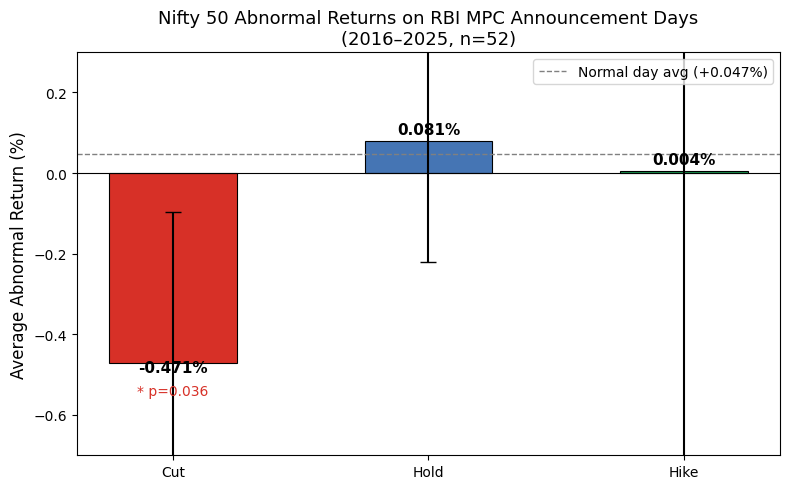

Chart 1 saved.


In [9]:
# Chart 1: Abnormal returns by decision type
fig, ax = plt.subplots(figsize=(8, 5))

decisions_order = ['Cut', 'Hold', 'Hike']
means = [mpc_df[mpc_df['Decision']==d]['Abnormal_Return'].mean() for d in decisions_order]
colors = ['#d73027', '#4575b4', '#1a9850']

bars = ax.bar(decisions_order, means, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + (0.01 if val >= 0 else -0.03),
            f'{val:.3f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Reference line
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(nifty_raw['Return'].mean(), color='gray', linewidth=1, 
           linestyle='--', label=f'Normal day avg (+{nifty_raw["Return"].mean():.3f}%)')

ax.set_ylabel('Average Abnormal Return (%)', fontsize=12)
ax.set_title('Nifty 50 Abnormal Returns on RBI MPC Announcement Days\n(2016–2025, n=52)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(-0.7, 0.3)

# Significance annotation
ax.text(0, -0.55, '* p=0.036', ha='center', fontsize=10, color='#d73027')

# Add error bars (95% CI = 1.96 * std / sqrt(n))
for i, decision in enumerate(decisions_order):
    d = mpc_df[mpc_df['Decision']==decision]['Abnormal_Return'].dropna()
    ci = 1.96 * d.std() / np.sqrt(len(d))
    ax.errorbar(i, d.mean(), yerr=ci, color='black', capsize=6, linewidth=1.5)

plt.tight_layout()
plt.savefig('../outputs/figures/chart1_abnormal_returns_by_decision.png', dpi=150)
plt.show()
print("Chart 1 saved.")

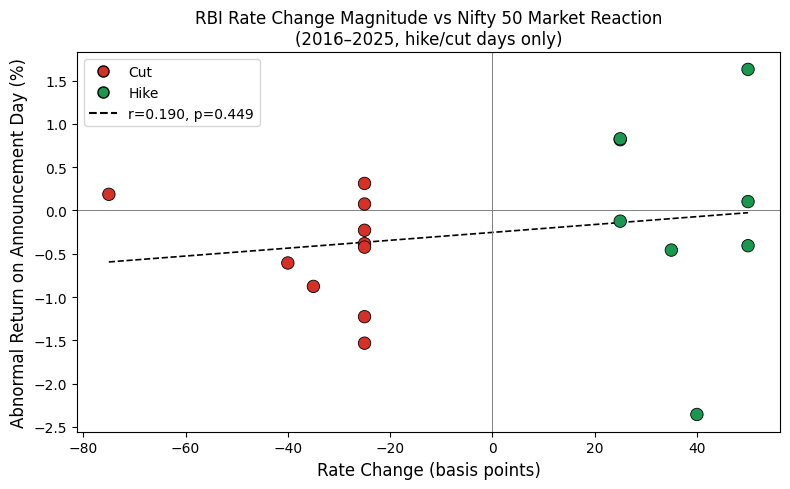

Correlation: r=0.190, p=0.449


In [10]:
%matplotlib inline
# Chart 2: Rate change magnitude vs Nifty return
# Exclude Hold days (Rate_Change_bps = 0) — no rate change, nothing to correlate
scatter_df = mpc_df[mpc_df['Rate_Change_bps'] != 0].copy()

fig, ax = plt.subplots(figsize=(8, 5))

colors = scatter_df['Decision'].map({'Cut': '#d73027', 'Hike': '#1a9850'})

ax.scatter(scatter_df['Rate_Change_bps'], scatter_df['Abnormal_Return'],
           c=colors, s=80, edgecolors='black', linewidth=0.6, zorder=3)

# Regression line
from numpy.polynomial.polynomial import polyfit
x = scatter_df['Rate_Change_bps']
y = scatter_df['Abnormal_Return']
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 
        color='black', linewidth=1.2, linestyle='--', label=f'Slope: {slope:.4f}')

# Correlation
corr, p_corr = stats.pearsonr(x, y)

# Reference lines
ax.axhline(0, color='gray', linewidth=0.7)
ax.axvline(0, color='gray', linewidth=0.7)

# Legend proxies for decision type
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d73027', 
           markersize=8, markeredgecolor='black', label='Cut'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1a9850', 
           markersize=8, markeredgecolor='black', label='Hike'),
]
ax.legend(handles=legend_elements + [
    Line2D([0], [0], color='black', linestyle='--', label=f'r={corr:.3f}, p={p_corr:.3f}')
], fontsize=10)

ax.set_xlabel('Rate Change (basis points)', fontsize=12)
ax.set_ylabel('Abnormal Return on Announcement Day (%)', fontsize=12)
ax.set_title('RBI Rate Change Magnitude vs Nifty 50 Market Reaction\n(2016–2025, hike/cut days only)', fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/figures/chart2_magnitude_vs_return.png', dpi=150)
plt.show()
print(f"Correlation: r={corr:.3f}, p={p_corr:.3f}")

In [13]:
worst_hike = mpc_df[(mpc_df['Decision']=='Hike')]['Abnormal_Return'].idxmin()
print(mpc_df.loc[worst_hike, ['Date','Rate_Change_bps','Abnormal_Return']])

Date               2022-05-04 00:00:00
Rate_Change_bps                     40
Abnormal_Return              -2.357864
Name: 34, dtype: object


In [14]:
hikes_excl_surprise = mpc_df[
    (mpc_df['Decision'] == 'Hike') & 
    (mpc_df['Date'] != pd.Timestamp('2022-05-04'))
]['Abnormal_Return']

print(f"Hikes excluding May 2022 surprise (n={len(hikes_excl_surprise)}):")
print(f"Mean: {hikes_excl_surprise.mean():.4f}%")
t, p = stats.ttest_1samp(hikes_excl_surprise, 0)
print(f"t={t:.3f}, p={p:.3f}")

Hikes excluding May 2022 surprise (n=7):
Mean: 0.3418%
t=1.168, p=0.287


In [15]:
# Formally classify all off-cycle emergency meetings
emergency_dates = ['2020-03-27', '2020-05-22', '2022-05-04']
mpc_df['Meeting_Type'] = mpc_df['Date'].isin(
    pd.to_datetime(emergency_dates)
).map({True: 'Emergency', False: 'Scheduled'})

print(mpc_df['Meeting_Type'].value_counts())
print()

# Clean summary: scheduled meetings only
scheduled = mpc_df[mpc_df['Meeting_Type'] == 'Scheduled']
print("=== Scheduled MPC Meetings Only ===")
print(scheduled.groupby('Decision')['Abnormal_Return'].agg(['mean','std','count']).round(4))

Meeting_Type
Scheduled    49
Emergency     3
Name: count, dtype: int64

=== Scheduled MPC Meetings Only ===
            mean     std  count
Decision                       
Cut      -0.5358  0.6340      8
Hike      0.3418  0.7746      7
Hold      0.0807  0.8934     34


In [16]:
print("=== Scheduled Meetings: Significance Tests ===\n")

for decision in ['Cut', 'Hike', 'Hold']:
    data = scheduled[scheduled['Decision']==decision]['Abnormal_Return'].dropna()
    t, p = stats.ttest_1samp(data, 0)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"{decision} (n={len(data)}): mean={data.mean():.4f}%  t={t:.3f}  p={p:.3f}  {sig}")

=== Scheduled Meetings: Significance Tests ===

Cut (n=8): mean=-0.5358%  t=-2.390  p=0.048  SIGNIFICANT
Hike (n=7): mean=0.3418%  t=1.168  p=0.287  not significant
Hold (n=34): mean=0.0807%  t=0.526  p=0.602  not significant


In [17]:
# Download sectoral indices
print("Downloading sectoral data...")
sector_tickers = {
    'Bank': '^NSEBANK',
    'IT': '^CNXIT',
    'FMCG': '^CNXFMCG',
    'Auto': '^CNXAUTO'
}

sector_data = {}
for name, ticker in sector_tickers.items():
    df = yf.download(ticker, start='2015-01-01', end='2025-12-31', progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['Return'] = df['Close'].pct_change() * 100
    sector_data[name] = df
    print(f"{name}: {len(df)} rows")

print("\nAll sectors downloaded.")

Bank: 2712 rows
IT: 2712 rows
FMCG: 2697 rows
Auto: 2698 rows

All sectors downloaded.


In [18]:
# Map sectoral returns to scheduled MPC dates
for sector_name, sector_df in sector_data.items():
    sector_returns = sector_df['Return'].copy()
    if sector_returns.index.tz is not None:
        sector_returns.index = sector_returns.index.tz_localize(None)
    sector_returns.index = sector_returns.index.normalize()
    scheduled[sector_name + '_Return'] = scheduled['Date'].map(sector_returns)

# Check coverage
sector_cols = ['Bank_Return', 'IT_Return', 'FMCG_Return', 'Auto_Return']
print("Missing values per sector:")
print(scheduled[sector_cols].isna().sum())

# Heatmap data: average return by decision type
heatmap_data = scheduled.groupby('Decision')[sector_cols].mean().round(3)
heatmap_data.columns = ['Bank', 'IT', 'FMCG', 'Auto']
print("\nHeatmap data:")
print(heatmap_data)

Missing values per sector:
Bank_Return    0
IT_Return      0
FMCG_Return    0
Auto_Return    0
dtype: int64

Heatmap data:
           Bank     IT   FMCG   Auto
Decision                            
Cut      -0.853 -0.126 -0.445 -0.137
Hike      0.396  0.552  0.248  0.131
Hold      0.245  0.309 -0.075  0.152


C:\Users\aathi\AppData\Local\Temp\ipykernel_16232\1496320063.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scheduled[sector_name + '_Return'] = scheduled['Date'].map(sector_returns)
C:\Users\aathi\AppData\Local\Temp\ipykernel_16232\1496320063.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scheduled[sector_name + '_Return'] = scheduled['Date'].map(sector_returns)
C:\Users\aathi\AppData\Local\Temp\ipykernel_16232\1496320063.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

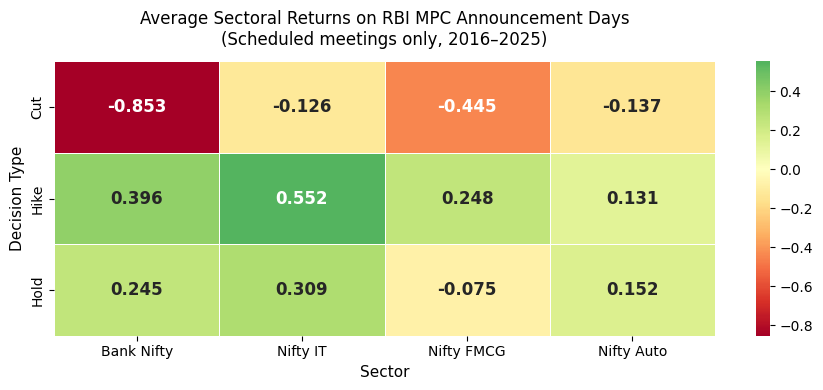

Chart 3 saved.


In [19]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.heatmap(heatmap_data, 
            annot=True, fmt='.3f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title('Average Sectoral Returns on RBI MPC Announcement Days\n(Scheduled meetings only, 2016–2025)', 
             fontsize=12, pad=12)
ax.set_xlabel('Sector', fontsize=11)
ax.set_ylabel('Decision Type', fontsize=11)
ax.set_xticklabels(['Bank Nifty', 'Nifty IT', 'Nifty FMCG', 'Nifty Auto'], fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/chart3_sectoral_heatmap.png', dpi=150)
plt.show()
print("Chart 3 saved.")

In [20]:
# Is Bank's cut-day reaction significantly negative?
bank_cuts = scheduled[scheduled['Decision']=='Cut']['Bank_Return'].dropna()
t, p = stats.ttest_1samp(bank_cuts, 0)
print(f"Bank Nifty on cut days (n={len(bank_cuts)}): mean={bank_cuts.mean():.3f}%, t={t:.3f}, p={p:.3f}")


Bank Nifty on cut days (n=8): mean=-0.853%, t=-2.338, p=0.052
